# Curating samples from the xView dataset

Pipeline so far (previous notebooks in this series):
- select a promising image tile (e.g. a lot of cars, visually selected etc)
- sample locations from there and output to `to_annotate` folder, with a separate dataframe per tile, pre-annotated (note, these images are **not** the same as will be fed to model, they have an extended bbox to help visual inspection) 
- annotate roads interactively using `ipyannotations` and append the labels as a column, then save

This notebooks reads in all the annotated dataframes, and also adds random locations (which will not have labels, to boost sample size and leverage DEARs capability for semi-supervision)

### WARNING: in xView_0 there was a bug - correcting here

Partway through I realised that B marking was faulty as forgot to divide by `res**2` for the built_area, and corrected it

In [1]:
# re-loads code before cell execution, so if sth changes it will propagate:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys

import time as tm
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from PIL import Image
from functools import partial

sys.path.append('..')

import src.plotting as splo
import src.data_utils as sdut
import src.geometry as sgeo
import src.sampling as ssam

## Set up namespace, e.g. point to data

In [3]:
data_path = '../data/xView-train_images-subset/'
label_path = '../data/xView_0/labels/'
resolution = 128

out_path = '../data/xView_0_fix/images/'
out_label_path = '../data/xView_0_fix/labels.csv'

In [4]:
def combo_string(x):
    if x['roads'] == -1:
        return ''
    else:
        return str(x['buildings'])+str(x['roads'])+str(x['cars'])

def combine_labels( folder, res= 128, add_unlabelled= False):
    label_files = os.listdir( folder)
    assert all([f.endswith('.csv') for f in label_files])
    df = pd.DataFrame()
    for file in label_files:
        df_ = pd.read_csv(f'{folder}{file}')
        to_drop = df_.loc[ df_['labels'] == 'reject'].index
        df_.drop( labels= to_drop, inplace= True)
        if max( df_['built_area']) > 4:
            print('Correcting built area to be a proportion of image!')
            df_['built_area'] = df_['built_area'] / (res**2)
        df_['buildings'] = ( df_['built_area'] > 0.25).astype(int)
        df_['cars'] = (df_['n_cars'] + df_['n_bus_trucks'] > 0).astype(int)
        df_['roads'] = df_['roads'].fillna(0).astype(int)
        #df_['B_R_C'] = df_.apply( lambda x: f'{x.buildings}{x.roads}{x.cars}', axis= 1)
        print(f'File {file}, keeping {len(df_)} entries.')
        df = pd.concat([df,df_])
    df['bbox_np'] = df['bbox_np'].map( lambda x: [int(y.strip('[]')) for y in x.split(',')])
    df['im_source'] = df.im_name.str.split('for_tiff').map( lambda x: x[0]).str.split('_').map( lambda x: x[0])
    df['image'] = 'tif' + df['im_source'] + '_x' + df['xs'].astype(str) + '_y' + df['ys'].astype(str) + '.png'
    df.loc[ df['labels']=='unlabel',['buildings','roads','cars']] = -1, -1, -1
    df['B_R_C'] = df.apply( combo_string, axis= 1)
    df.reset_index( inplace= True, drop= True)
    return df

def add_unlabelled_safe( dfs, im_dims, im_name, res= 128):
    """
    This assumes dfs is a slice of the larger frame.
    """
    n_lab = len( dfs.loc[ dfs['roads']>= 0])
    cols_output = ['image','xs','ys','bbox_np','buildings','roads','cars']
    df_new = dfs[['xs','ys']].copy()
    # offset and add jitter:
    df_new['xs'] += 40 + np.random.uniform(1,5,len(df_new)).astype(int)
    df_new['ys'] += 60 + np.random.uniform(2,10,len(df_new)).astype(int)
    df_new['bbox_np'] = df_new.apply(
        lambda x: ssam.square_bbox_around( x['xs'], x['ys'], res= res), axis= 1
    ).map(
        lambda x: [int(y) for y in x]
    )
    df_new[['buildings','roads','cars']] = -1,-1,-1
    df_new['image'] = df_new.apply( lambda x: ssam.name_sample_image( im_name, x['xs'], x['ys']), axis= 1)
    df_add = ssam.prep_samples_unlabelled(
        im_dims, im_name, n_lab, res, int(im_name), shift_min= 30
    )
    dfs_ = pd.concat([dfs[cols_output],df_add,df_new])
    dfs_.reset_index( drop=True, inplace=True)
    dfs_.sort_values(by=['xs','ys'],inplace=True)
    dfs_ = ssam.filter_xy( dfs_, int( res/ 5))
    n_lab_new = len( dfs_.loc[ dfs_['roads'] >=0])
    try:
        assert n_lab_new == n_lab
    except AssertionError:
        print(f'Lost {n_lab - n_lab_new} labels')
    return dfs_

## Investigate data, try things out 

_**you can even add fancy markdown throughout to document things..?**_

In [5]:
df = combine_labels( label_path)
df.shape

Correcting built area to be a proportion of image!
File for_tiff102.csv, keeping 411 entries.
Correcting built area to be a proportion of image!
File for_tiff1037.csv, keeping 142 entries.
Correcting built area to be a proportion of image!
File for_tiff104.csv, keeping 117 entries.
Correcting built area to be a proportion of image!
File for_tiff105.csv, keeping 113 entries.
Correcting built area to be a proportion of image!
File for_tiff1051.csv, keeping 225 entries.
Correcting built area to be a proportion of image!
File for_tiff106.csv, keeping 287 entries.
Correcting built area to be a proportion of image!
File for_tiff1063.csv, keeping 169 entries.
Correcting built area to be a proportion of image!
File for_tiff1065.csv, keeping 104 entries.
Correcting built area to be a proportion of image!
File for_tiff107.csv, keeping 249 entries.
Correcting built area to be a proportion of image!
File for_tiff109.csv, keeping 351 entries.
File for_tiff110.csv, keeping 147 entries.
File for_tiff

(3003, 16)

In [6]:
df_ = df.loc[ df['labels'] != 'unlabel']
df_.shape

(2293, 16)

<Axes: xlabel='B_R_C'>

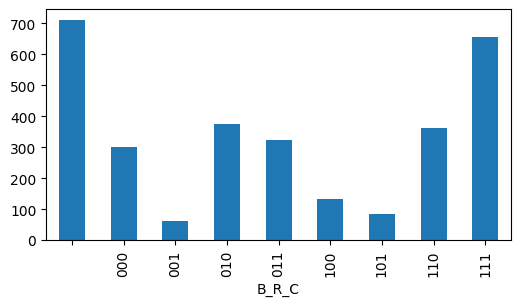

In [7]:
_, ax = plt.subplots( figsize= (6,3))
df.groupby('B_R_C').count()['xs'].plot(kind='bar', ax= ax)

In [8]:
df.groupby('im_source').agg({'built_area':['min','max']})

built_area          
                 min       max
im_source                     
102         0.000000  1.485840
1037        0.000000  1.000000
104         0.000000  1.382080
105         0.000000  1.457703
1051        0.000000  1.709961
106         0.000000  1.211060
1063        0.000000  1.227051
1065        0.000000  1.470459
107         0.000000  2.492920
109         0.000000  1.352478
110         0.131165  1.157593
1121        0.000000  1.909973
1124        0.000000  1.199646
1132        0.000000  1.691589

Loop through the unique source images, for each add further unlabelled data (some offset, some random)

In [9]:
start = tm.time()

df_out = pd.DataFrame()
for im_src_ in df['im_source'].unique():
    im_src_path = f'{data_path}{im_src_}.tif'
    print(f'Loading {im_src_path}')
    image_ = np.array( Image.open( im_src_path))
    xmax, ymax, _ = image_.shape
    dfs = df.loc[ df['im_source'] == im_src_]
    dfs_ = add_unlabelled_safe( dfs, (xmax, ymax), im_src_, res= resolution)
    df_out = pd.concat( [df_out, dfs_])
    for bbox_, name_ in zip( dfs_['bbox_np'], dfs_['image']):
        Image.fromarray( sgeo.crop_to_bbox( image_, bbox_)).save( f'{out_path}{name_}')
    
df_out.reset_index( drop= True, inplace= True)
df_out['B_R_C'] = df_out.apply( combo_string, axis= 1)

df_out.to_csv( out_label_path, index= False)

print(f'\nTook {np.round((tm.time()-start)/60,3)} mins, output {len(df_out)} images, saved labels to {out_label_path}.')
len(df_out.loc[ df_out['B_R_C']!='']), len(df_out)

Loading ../data/xView-train_images-subset/102.tif
Lost 1 labels
Loading ../data/xView-train_images-subset/1037.tif
Loading ../data/xView-train_images-subset/104.tif
Loading ../data/xView-train_images-subset/105.tif
Loading ../data/xView-train_images-subset/1051.tif
Loading ../data/xView-train_images-subset/106.tif
Loading ../data/xView-train_images-subset/1063.tif
Lost 4 labels
Loading ../data/xView-train_images-subset/1065.tif
Lost 3 labels
Loading ../data/xView-train_images-subset/107.tif
Loading ../data/xView-train_images-subset/109.tif
Loading ../data/xView-train_images-subset/110.tif
Lost 1 labels
Loading ../data/xView-train_images-subset/1121.tif
Loading ../data/xView-train_images-subset/1124.tif
Loading ../data/xView-train_images-subset/1132.tif
Lost 1 labels

Took 0.683 mins, output 8176 images, saved labels to ../data/xView_0_fix/labels.csv.


(2283, 8176)

<Axes: xlabel='B_R_C'>

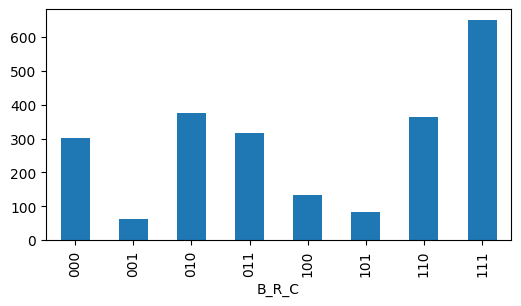

In [10]:
_, ax = plt.subplots( figsize= (6,3))
dfg = df_out.groupby('B_R_C').count()['xs']
dfg.loc[ dfg.index != ''].plot(kind='bar', ax= ax)

In [11]:
len(df_out['image'].unique()) == len(df_out)

True

In [12]:
set(df_out['image'].unique()) == set(os.listdir( out_path))

True

In [13]:
df_out.head(5)

,image,xs,ys,bbox_np,buildings,roads,cars,B_R_C
0,tif102_x65_y1613.png,65,1613,"[1, 1549, 129, 1677]",-1,-1,-1,
1,tif102_x66_y1445.png,66,1445,"[2, 1381, 130, 1509]",-1,-1,-1,
2,tif102_x67_y370.png,67,370,"[3, 306, 131, 434]",-1,-1,-1,
3,tif102_x67_y1496.png,67,1496,"[3, 1432, 131, 1560]",-1,-1,-1,
4,tif102_x79_y648.png,79,648,"[15, 584, 143, 712]",1,1,0,110
